Assiment 2
Marah Amjad Qandeel
2320226461


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
path = '/content/drive/MyDrive/mathes.csv'

df_all = pd.read_csv(path)

# 4. أخذ أول 500 صف فقط )
df = df_all.head(500).copy()
print(df.info())

print(df.head())




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Team name         500 non-null    object
 1   Match date        500 non-null    object
 2   Opponent team     500 non-null    object
 3   Match result      500 non-null    object
 4   Competition name  500 non-null    object
dtypes: object(5)
memory usage: 19.7+ KB
None
       Team name   Match date  Opponent team Match result Competition name
0  united-states  Tue, Nov 18  United States        5 - 1          Uruguay
1  united-states  Sat, Nov 15  United States        2 - 1         Paraguay
2  united-states  Tue, Oct 14  United States        2 - 1        Australia
3  united-states  Fri, Oct 10  United States        1 - 1          Ecuador
4  united-states   Tue, Sep 9  United States        2 - 0            Japan


In [19]:
print(df.isnull().sum())
#إزالة الصفوف المكررة
df= df.drop_duplicates()

# 1. تنظيف أسماء الأعمدة من أي مسافات مخفية في البداية أو النهاية
df.columns = df.columns.str.strip()

# ازالة المسافات الزائدة

df['Team name'] = df['Team name'].str.strip()
df['Opponent team'] = df['Opponent team'].str.strip()


# تحويل التاريخ من نص الي تاريخ
df['Match date'] = pd.to_datetime(df['Match date'],format='%a, %b %d', errors='coerce')

Team name           0
Match date          0
Opponent team       0
Match result        0
Competition name    0
dtype: int64


In [20]:

split_data= df['Match result'].str.split('-',expand=True)
df['Team Goals']= pd.to_numeric(split_data[0].str.strip(),errors='coerce')
df['Opponent Goals']=pd.to_numeric(split_data[1].str.strip(),errors='coerce')
   #حذف اي صفوف اصبحت فارغة
df = df.dropna(subset=['Team Goals', 'Opponent Goals'])
# تحديد حالة المباراة
def get_match_result(row):
  if row['Team Goals'] > row ['Opponent Goals']:
    return 'win'
  elif row['Team Goals'] < row ['Opponent Goals']:
    return 'loss'
  else:
    return 'Draw'
df['Status'] = df.apply(get_match_result ,axis=1)
print('Data cleaning and status column addition successful!')
print(f'Number of rows remaining after cleaning : {len(df)}')
print(df[['Match result', 'Team Goals', 'Opponent Goals', 'Status']].head())


Data cleaning and status column addition successful!
Number of rows remaining after cleaning : 255
  Match result  Team Goals  Opponent Goals Status
0        5 - 1           5             1.0    win
1        2 - 1           2             1.0    win
2        2 - 1           2             1.0    win
3        1 - 1           1             1.0   Draw
4        2 - 0           2             0.0    win


In [21]:
print("أعلى أهداف سجلها فريقي:", df['Team Goals'].max())

أعلى أهداف سجلها فريقي: 10


$$X_{new} = \frac{X_{current} - X_{min}}{X_{max} - X_{min}}$$
تقوم أداة MinMaxScaler بتحويل كل قيمة في عمود الأهداف (Team Goals و Opponent Goals) إلى قيمة جديدة تقع في النطاق ما بين 0 و 1.

In [22]:
# NORMALIZATION
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[['Team Goals Norm', 'Opponent Goals Norm']] = scaler.fit_transform(df[['Team Goals', 'Opponent Goals']])
print('Normalization has been performed using the library Sklearn"')
print(df[['Team Goals', 'Team Goals Norm']].head())
print(df[['Opponent Goals', 'Opponent Goals Norm']].head())

# عرض أعلى قيم بعد التطبيع
print("Highest normalized value for my team:", df['Team Goals Norm'].max())

Normalization has been performed using the library Sklearn"
   Team Goals  Team Goals Norm
0           5              0.5
1           2              0.2
2           2              0.2
3           1              0.1
4           2              0.2
   Opponent Goals  Opponent Goals Norm
0             1.0             0.166667
1             1.0             0.166667
2             1.0             0.166667
3             1.0             0.166667
4             0.0             0.000000
Highest normalized value for my team: 1.0


Data Visualization

/tmp/ipython-input-3905241862.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Status', palette='viridis')


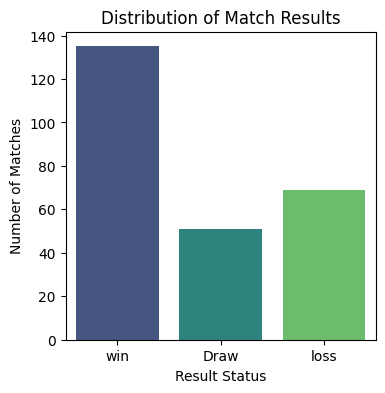

In [23]:
#1- Destrpution Match Results (win,loss.draw)
plt.figure(figsize=(4,4))
sns.countplot(data=df, x='Status', palette='viridis')
plt.title('Distribution of Match Results')
plt.xlabel('Result Status')
plt.ylabel('Number of Matches')
plt.show()

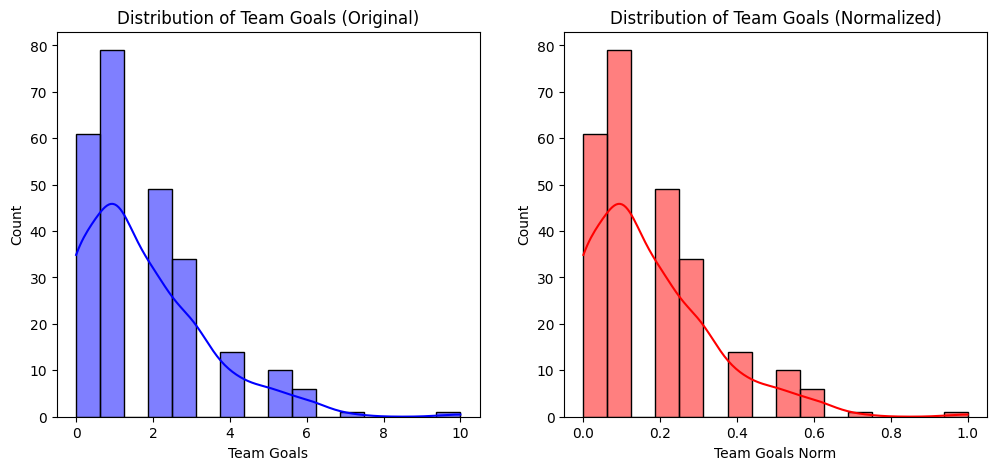

In [24]:


#2-Distribution Goals (before and after normalization)
plt.figure(figsize=(12,5))

#goal the team
plt.subplot(1,2,1)
sns.histplot(df['Team Goals'],kde=True,color='blue')
plt.title('Distribution of Team Goals (Original)')


#goal the team after normalization
plt.subplot(1,2,2)
sns.histplot(df['Team Goals Norm'],kde=True,color='red')
plt.title('Distribution of Team Goals (Normalized)')

plt.show()


In [25]:
#3- Relationship between goals team and oppentent team
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,y='Opponent Gols',hue='Status', style='Status', s=100)
plt.xlabel('Team Goals')
plt.ylabel(;)
plt.title('Team Goals vs Opponent Goals')
plt.show()

SyntaxError: invalid syntax (ipython-input-2320117495.py, line 5)

In [26]:
df.to_csv('final_processed_mathes.csv', index=False)
print(" final_processed_mathes.csv")

 final_processed_mathes.csv
